# Netflix Movie Data Analysis

## Project Description:
#### The goal of this project was to explore trends and patterns in Netflix's movie catalog by analyzing their popularity, voting patterns, genres, and release timelines. Through this analysis, I aimed to identify the most dominant movie genres, find the highest and lowest-rated films, understand audience preferences based on popularity and voting, and discover which years saw the most movie releases. This project involved data cleaning, insightful visualizations, and drawing actionable insights to better understand the content strategy of Netflix.



### Key Questions:

1. What is the most frequent genre of movies released on Netflix?

2. Which movie has the highest vote in the vote average column?

3. What movie has the highest popularity and what is its genre?

4. What movie has the lowest popularity and what is its genre?

5. Which year has the highest number of movies released?

In [2]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# Loading the dataset
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')

In [4]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [5]:
# viewing dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


#### Conclusion: 
#### The dataset has no missing (NaN) values, which is good.
#### Overview, Original_Language, and Poster_Url columns are less useful for our analysis goals and can be ignored or dropped.
#### The Release_Date column is currently of type object and should be converted to datetime to extract the year for better analysis.

In [6]:
# exploring genres column

df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

#### Conclusion : Genres are separated by commas and extra spaces, which needs to be cleaned up for consistency.

In [7]:
# check for duplicate rows

df.duplicated().sum()

0

#### Conclusion: No duplicate rows were found in the dataset, indicating that each entry is unique and does not need to be removed or handled.

In [8]:
# exploring summary statistics
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


#### Exploration Summary
. The dataframe consists of 9827 rows and 9 columns.

. The dataset appears to be clean with no missing values (NaNs) and no duplicate rows.

. The Release_Date column needs to be casted into datetime format to extract just the year for better analysis.

. The Overview, Original_Language, and Poster_Url columns are not very useful for our analysis and can be ignored or dropped.

. The Vote_Average column would be better if categorized (e.g., into rating bins) for easier analysis.

. The Genre column contains comma-separated values with extra spaces, which need to be cleaned for proper analysis.

### Data Cleaning

In [9]:
# Cast Release_Date to datetime
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)

# Extract only the year and overwrite the same Release_Date column
df['Release_Date'] = df['Release_Date'].dt.year
print(df['Release_Date'].dtype)


datetime64[ns]
int32


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   int32  
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(5)
memory usage: 652.7+ KB


In [11]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [12]:
# Drop Overview, Original_Language, and Poster_Url columns
df.drop(['Overview', 'Original_Language', 'Poster_Url'], axis=1, inplace=True)


In [13]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [14]:
#categorizing Vote_Average column
#We would cut the Vote_Average values and make 4 categories: 
#popular, average, below_avg , not_popular to describe it more using catigorize_col() function provided above.


def catigorize_col(df, col, labels):
    """
    Categorizes a certain column based on its quartiles.

    Args:
        df (pd.DataFrame): DataFrame we are processing
        col (str): The column's name to be categorized
        labels (list): List of labels from min to max

    Returns:
        df (pd.DataFrame): DataFrame with the categorized column
    """

    # Setting the edges to cut the column accordingly
    edges = [
        df[col].describe()['min'],  # minimum value
        df[col].describe()['25%'],  # first quartile (Q1)
        df[col].describe()['50%'],  # median (Q2)
        df[col].describe()['75%'],  # third quartile (Q3)
        df[col].describe()['max']   # maximum value
    ]

    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop') #pd.cut()` is used to **divide** the column into **intervals** based on the `edges`. 
    return df




In [15]:
# Define labels for edges
labels = ['not_popular', 'below_avg', 'average', 'popular']

# Categorize column based on labels and edges
df = catigorize_col(df, 'Vote_Average', labels)

# Confirming changes
print(df['Vote_Average'].unique())


['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']


In [16]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [17]:
# exploring column
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [18]:
# dropping NaNs
df.dropna(inplace = True)
# confirming
df.isna().sum()


Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [19]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [20]:
# we'd split genres into a list and then explode our dataframe to have only one genre per row for each movie

# split the strings into lists
df['Genre'] = df['Genre'].str.split(', ')
# explode the lists
df = df.explode('Genre').reset_index(drop=True)
df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [21]:
# casting column into category
df['Genre'] = df['Genre'].astype('category')
# confirming changes
df['Genre'].dtypes


CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [22]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


#### Conclusion: Now that our dataset is clean and tidy, we are left with a total of 6 columns and 25551 rows to dig into during our analysis


## Data Visualization

In [24]:
# setting up seaborn configurations
sns.set_style('whitegrid')


## Q1: What is the most frequent genre in the dataset?


In [25]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

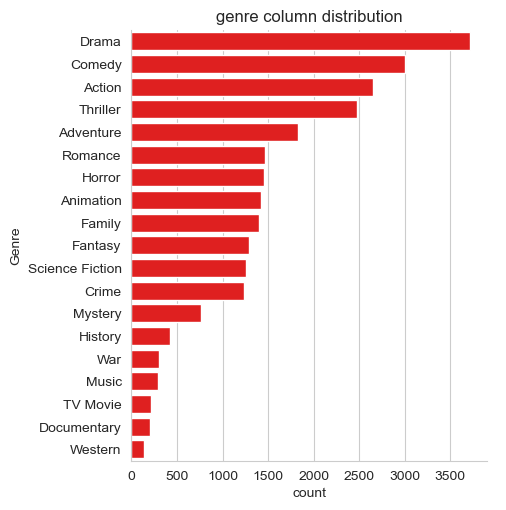

In [27]:
sns.catplot(y = 'Genre', data = df, kind = 'count',
           order = df['Genre'].value_counts().index,
           color = 'red')
plt.title('genre column distribution')
plt.show()

#### Conclusion: we can notice from the above visual that Drama genre is the most frequent genre in our dataset 

## Q2: What genres has highest votes ?

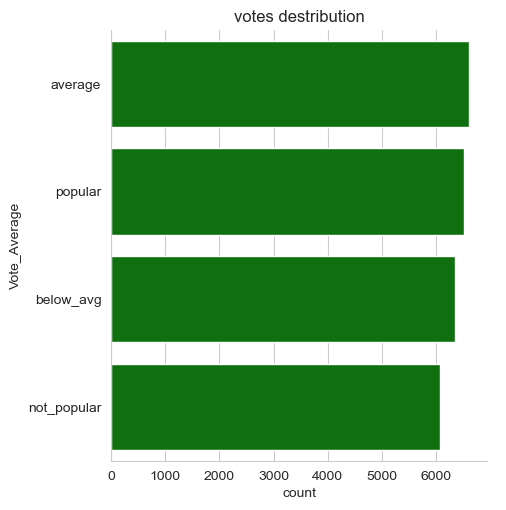

In [28]:
# visualizing vote_average column
sns.catplot(y = 'Vote_Average', data = df, kind = 'count',
 order = df['Vote_Average'].value_counts().index,
 color = 'green')
plt.title('votes destribution')
plt.show()

## Q3: What movie got the highest popularity ? what's its genre ?

In [29]:
# checking max popularity in dataset
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


#### Conclusion: Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action , Adventure and Sience Fiction .

## Q4: What movie got the lowest popularity ? what's its genre ?


In [30]:
# checking min popularity in dataset
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


#### Conclusion: The united states, thread' has the  lowest rate in our dataset and it has genres of music , drama , 'war', 'sci-fi' and history`.

## Q5: Which year has the most filmmed movies?

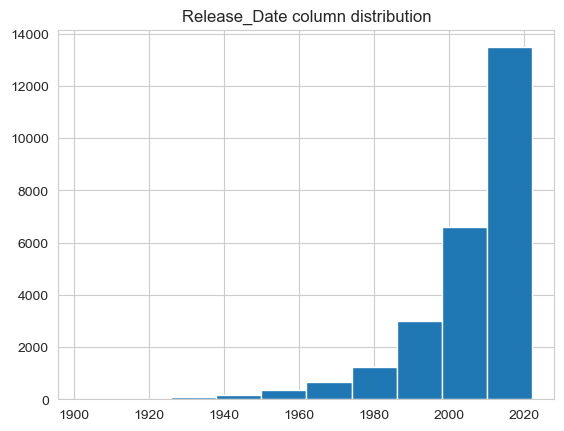

In [31]:
df['Release_Date'].hist()
plt.title('Release_Date column distribution')
plt.show()

#### Conclusion: year 2020 has the highest filmming rate in our dataset